# Ley de Torricelli
La velocidad de salida del fluido depende de la altura que este tiene en su contenedor
\begin{equation}
v = \sqrt{2gH}
\end{equation}

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


Las condiciones para el problema del contenedor son:
- Por simetría:
$$v_x = \frac{\partial u}{\partial y} = 0$$


In [6]:
#Parametros
Nx = 60
Ny = 60

h = 0.4
omega = 0.1

g = 9.8
V0 = 8e-4

nu = 0.5
R = V0 * h / nu
Niter = 4000

#Geometría

Nb = 15
Ndown = 20

#campos
u = np.zeros((Nx + 1, Ny + 1), float)
w = np.zeros((Nx + 1, Ny + 1), float)

#posiciones de viga
def BelowHole():
    
    for i in range(Nb + 1, Nx + 1):
        u[i, 0] = u[i - 1, 1]
        w[i - 1, 0] = w[i - 1, 1]
        for j in range(0, Ndown + 1):
            if  i == Nb:
                vy = 0
            elif i == Nx:
                vy = - np.sqrt(2 * g * h * (Ny + Nb - j))
            elif i == Nx - 1:
                vy = - np.sqrt(2 * g * h * (Ny + Nb - j)) / 2
            else:
                vy = 0
            u[i, j] = u[i - 1, j] - vy * h
       
def BorderRight():

    for j in range(1, Ny + 1):

        vy = -np.sqrt(2 * g * h * (Ny - j))

        u[Nx, j] = u[Nx - 1, j] + vy * h

        u[Nx, j] = u[Nx, j - 1]

        w[Nx, j] = 2 * (u[Nx, j] - u[Nx, j - 1]) / h ** 2

def BottomBefore():

    for i in range(1, Nb + 1):

        u[i, Ndown] = u[i, Ndown - 1]

        w[i, Ndown] = -2 * (u[i, 0] - u[i, 1])

def Top():
    for i in range(1, Nx):
        u[i, Ny] = u[i, Ny - 1]
        w[i, Ny] = 0

def Left():

    for j in range(Ndown, Ny):
        w[0, j] = 2 * (u[0, j] - u[1, j]) / h ** 2

        u[0, j] = u[1, j]

def Borders():

    BelowHole()
    BorderRight()
    BottomBefore()
    Top()
    Left()

def Relax():
    Borders()

    #Resolver u
    for i in range(1, Nx):
        for j in range(1, Ny):
            r1 = omega * ((
                u[i + 1, j] + u[i - 1, j] +
                u[i, j + 1] + u[i, j - 1] +
                h * h * w[i, j]
            ) * 0.25 - u[i, j])
            u[i, j] += r1
    Borders() 

    #Resolver w
    for i in range(1, Nx):
        for j in range(1, Ny):
            a1 = ( w[i + 1, j] +
                  w[i - 1, j] +
                  w[i, j + 1] +
                  w[i, j - 1])
            a2 = ((u[i, j + 1] - u[i, j - 1]) * 
                  (w[i + 1, j] - w[i - 1, j]))
            a3 = ((u[i + 1, j] - u[i - 1, j]) * 
                  (w[i, j + 1] - w[i, j - 1]))
            r2 = omega * ((a1 + (R / 4.0) * (a3 - a2)) / 4.0 - w[i, j])
            w[i, j] += r2

In [8]:
#Iteraciones
for it in range(Niter):

    Relax()

    if it % 100 == 0:
        print('Iteración = ', it)

#Velocidades
vx = np.zeros_like(u)
vy = np.zeros_like(u)

for i in range(1, Nx):
    for j in range(1, Ny):
        vx[i, j] = (u[i, j + 1] - u[i, j - 1]) / (2* h)
        vy[i, j] = -(u[i + 1, j] - u[i - 1, j]) / (2 * h)

Iteración =  0
Iteración =  100
Iteración =  200
Iteración =  300
Iteración =  400
Iteración =  500
Iteración =  600
Iteración =  700
Iteración =  800
Iteración =  900
Iteración =  1000
Iteración =  1100
Iteración =  1200
Iteración =  1300
Iteración =  1400
Iteración =  1500
Iteración =  1600
Iteración =  1700
Iteración =  1800
Iteración =  1900
Iteración =  2000
Iteración =  2100
Iteración =  2200
Iteración =  2300
Iteración =  2400
Iteración =  2500
Iteración =  2600
Iteración =  2700
Iteración =  2800
Iteración =  2900
Iteración =  3000
Iteración =  3100
Iteración =  3200
Iteración =  3300
Iteración =  3400
Iteración =  3500
Iteración =  3600
Iteración =  3700
Iteración =  3800
Iteración =  3900


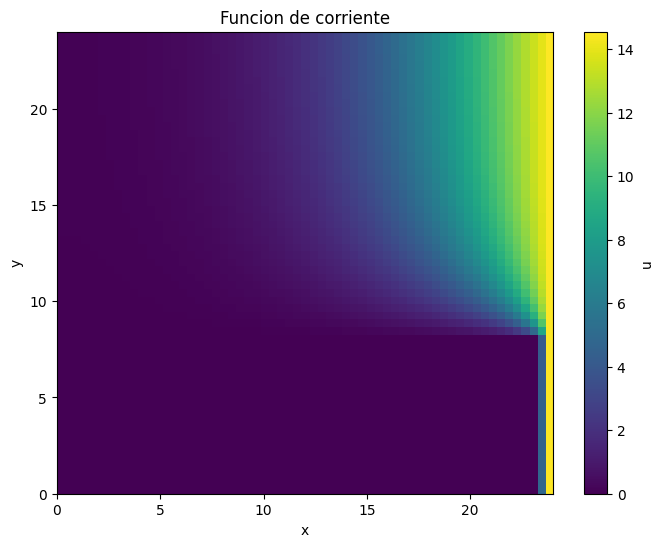

In [11]:
#Malla

x= np.arange(0, Nx + 1) * h
y = np.arange(0, Ny + 1) * h

X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8,6))

plt.imshow(
    u.T,
    origin = 'lower',
    extent = [0, Nx * h, 0, Ny * h],
    aspect = 'auto'
)

plt.colorbar(label = 'u')

plt.xlabel('x')
plt.ylabel('y')

plt.title('Funcion de corriente')

plt.show()

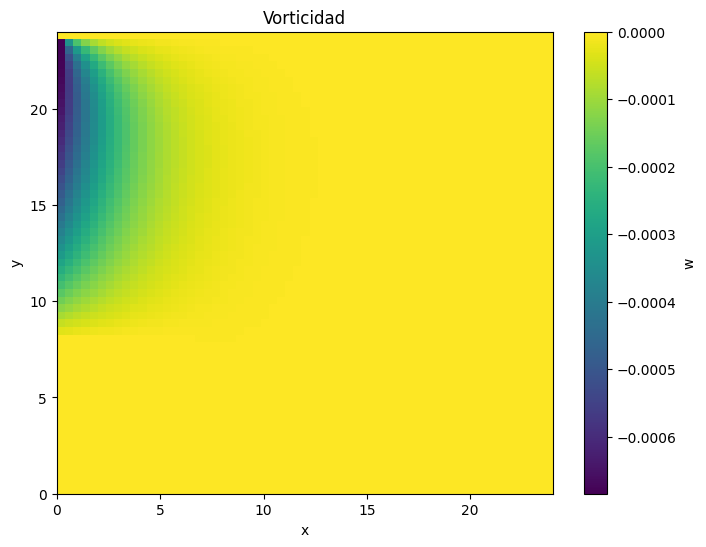

In [12]:
#vorticidad
plt.figure(figsize=(8,6))

plt.imshow(
    w.T,
    origin = 'lower',
    extent = [0, Nx * h, 0, Ny * h],
    aspect = 'auto'
)

plt.colorbar(label = 'w')

plt.xlabel('x')
plt.ylabel('y')

plt.title('Vorticidad')

plt.show()

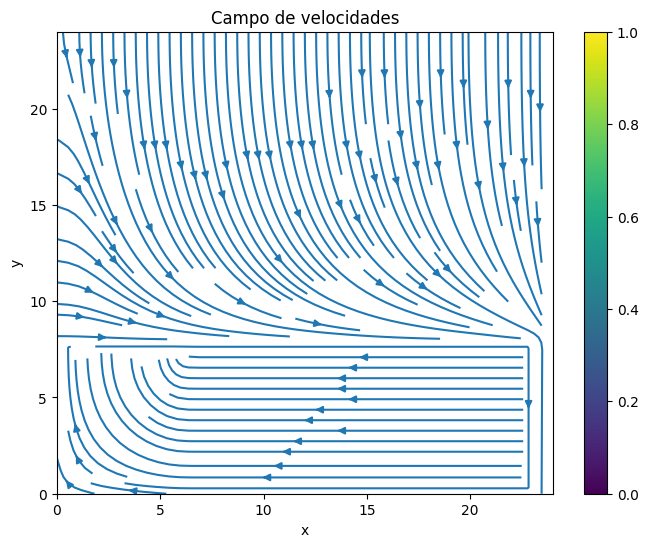

In [15]:
#Campo vectorial de velocidades
plt.figure(figsize=(8,6))

plt.streamplot(
    X, 
    Y, 
    vx.T,
    vy.T,
    density = 1.5
)
plt.colorbar()

plt.xlabel('x')
plt.ylabel('y')
plt.title('Campo de velocidades')

plt.show()

# Tanque cuadrado
Tenemos un tanque con dimensiones $30\ cm \times 30\ cm$, lleno de fluido incompresible.
El fluido:
- Entra por la pared iquierda
- sale por la pared derecha 
- tiene una velocidad de movimiento v0


In [ ]:
#Parámetros

Nx = 30
Ny = 30

h = 1.0

V0 = 18.0
u0 = 18.0

nu =25

omega = 0.1
